# Model Explainability

## Ford Car Price Prediction — AutoPrice AI Pro

### Objective

Understand why the machine learning model makes its predictions.

### Explainability techniques

1. XGBoost Feature Importance
2. Permutation Importance
3. SHAP
4. Individual Prediction Explanation
5. Error Analysis

### Champion Model

Baseline XGBoost

RMSE = 1002.41
R² = 0.96

In [1]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
import joblib

import shap

In [2]:
xgb_pipeline = joblib.load(
    "../models/xgb_pipeline.pkl"
)

In [3]:
xgb_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

In [4]:
best_model = xgb_pipeline

In [5]:
preprocessor = best_model.named_steps["preprocessor"]

In [6]:
xgb_model = best_model.named_steps["model"]

In [7]:
print(preprocessor)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 Index(['year', 'mileage', 'tax', 'mpg', 'engineSize', 'car_age',
       'mileage_per_year'],
      dtype='str')),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 Index(['model', 'transmission', 'fuelType', 'engine_category',
       'fuel_efficiency', 'tax_category'],
      dtype='str'))])


In [8]:
print(xgb_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)


In [9]:
df = pd.read_csv("../data/interim/featured_ford.csv")

In [10]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,car_age,mileage_per_year,engine_category,fuel_efficiency,tax_category,price_segment
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0,9,1594.400000,small,medium,medium,Premium
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0,8,1009.222222,small,medium,medium,Premium
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0,9,1245.600000,small,medium,medium,Premium
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5,7,1307.500000,medium,medium,medium,Luxury
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0,7,185.250000,small,medium,medium,Luxury


In [11]:
X = df.drop(["price" , "price_segment"] , axis=1)
y = df["price"]

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [14]:
best_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['model','year','transmission',...,'engine_category','fuel_efficiency', 'tax_category']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This s

In [15]:
predictions = best_model.predict(X_test)

In [16]:
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

mae = mean_absolute_error(predictions,y_test)
rmse = root_mean_squared_error(predictions, y_test)
r2 = r2_score(predictions, y_test)

print("MAE" , mae)
print("RMSE" , rmse)
print("R2 Score" , r2)

MAE 813.7642822265625
RMSE 1172.1351318359375
R2 Score 0.9333620071411133


In [17]:
predictions[:5]

array([7766.0215, 9275.708 , 8345.467 , 6303.652 , 3103.821 ],
      dtype=float32)

In [18]:
feature_names = preprocessor.get_feature_names_out()

print("No of Features" , len(feature_names))

print("XGBBoost :" , xgb_model.n_features_in_)

No of Features 48
XGBBoost : 48


In [19]:

importance_values = xgb_model.feature_importances_

In [20]:
feature_importance = pd.DataFrame({
    "Feature" : feature_names,
    "Importance" : importance_values
})

In [21]:
feature_importance =feature_importance.sort_values(
    by="Importance",
    ascending= False
)

In [22]:
feature_importance.head(10)

,Feature,Importance
22,cat__model_ Mustang,0.158260
4,num__engineSize,0.120380
0,num__year,0.113622
40,cat__engine_category_medium,0.088538
5,num__car_age,0.078907
41,cat__engine_category_small,0.062323
19,cat__model_ Ka+,0.058194
20,cat__model_ Kuga,0.050997
12,cat__model_ Fiesta,0.037895
10,cat__model_ Edge,0.032572


In [23]:
top_features = feature_importance.head(15)

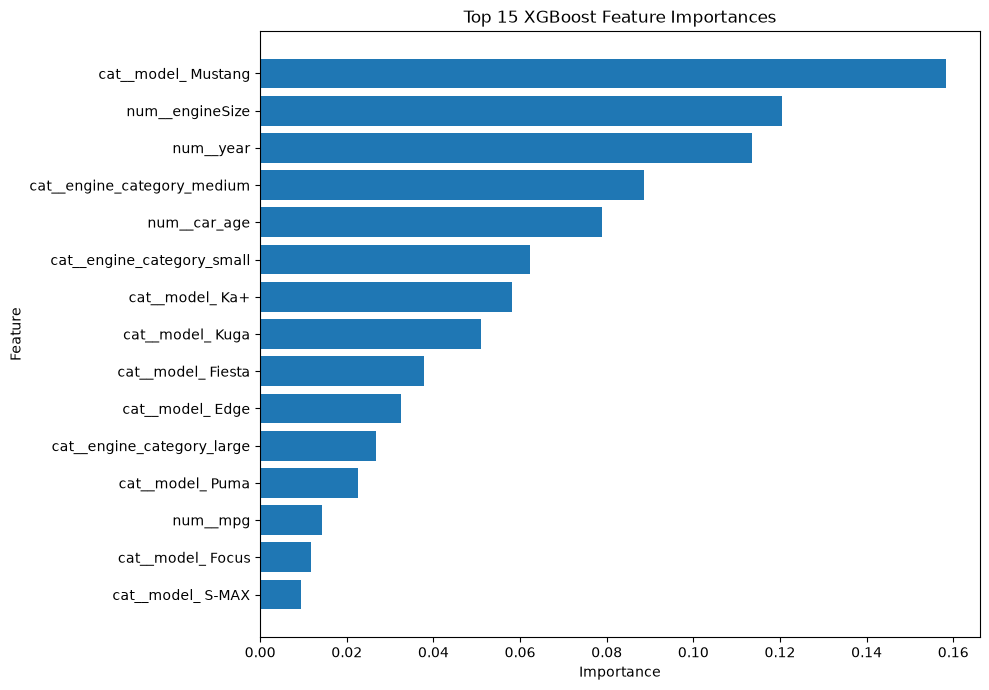

In [24]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")

plt.tight_layout()

plt.show()

In [25]:
feature_importance.head(20)

,Feature,Importance
22,cat__model_ Mustang,0.158260
4,num__engineSize,0.120380
0,num__year,0.113622
40,cat__engine_category_medium,0.088538
5,num__car_age,0.078907
41,cat__engine_category_small,0.062323
19,cat__model_ Ka+,0.058194
20,cat__model_ Kuga,0.050997
12,cat__model_ Fiesta,0.037895
10,cat__model_ Edge,0.032572


In [26]:
from sklearn.inspection import permutation_importance

In [30]:
permutation_result = permutation_importance(
    xgb_pipeline,
    X_test,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [31]:
permutation_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": permutation_result.importances_mean
})

In [32]:
permutation_importance_df = permutation_importance_df.sort_values(
    by="Importance",
    ascending=False
)

In [33]:
permutation_importance_df.head(20)

,Feature,Importance
1,year,2028.431616
7,engineSize,1922.634302
0,model,847.637756
3,mileage,653.582715
6,mpg,520.041956
8,car_age,64.008887
2,transmission,52.078625
9,mileage_per_year,48.071313
5,tax,40.013196
4,fuelType,18.025659


In [34]:
top_permutation = permutation_importance_df.head(15)

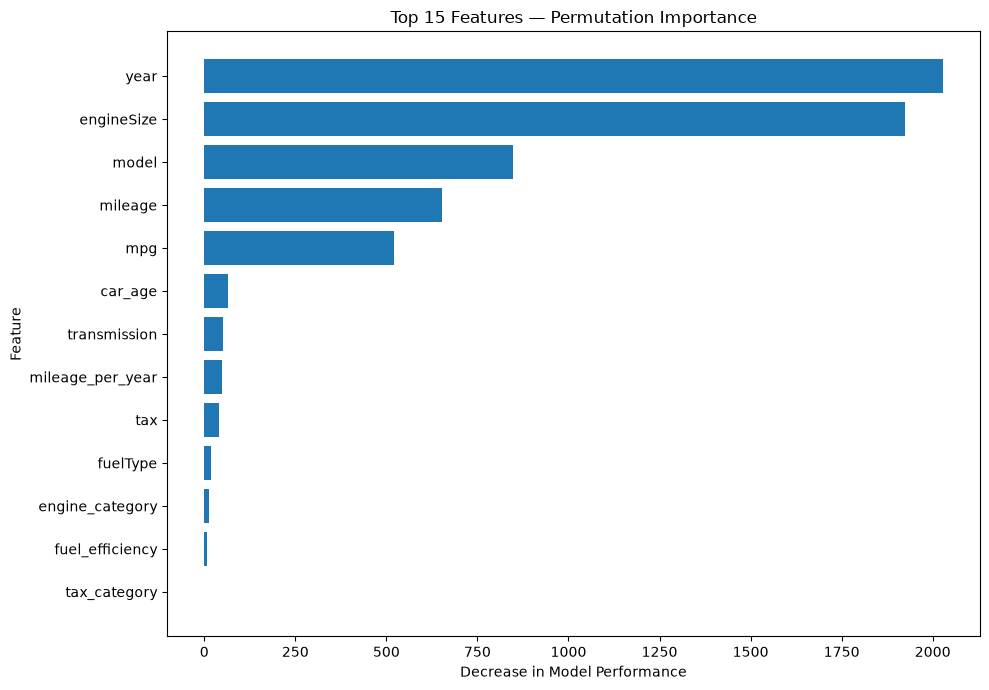

In [35]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_permutation["Feature"],
    top_permutation["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Decrease in Model Performance")
plt.ylabel("Feature")
plt.title("Top 15 Features — Permutation Importance")

plt.tight_layout()

plt.show()